## fine tuninng

In [1]:
import torch

print(f"Is CUDA actually awake?: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We are running on: {device}")

Is CUDA actually awake?: True
We are running on: cuda


In [2]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer

print("May the GPU gods have mercy on your soul...")

# 1. Load the RAW Tabular Data because we actually need the text to train the text model
df_train = pd.read_csv("../data/train.csv")
df_valid = pd.read_csv("../data/valid.csv")

#using complete training data now, as compared to the previously 90k samples from training data

# Create the text inputs and use the LOG-TRANSFORMED salaries as the labels
train_texts = (df_train['Title'].fillna("") + " | " + df_train['FullDescription'].fillna("")).tolist()
train_labels = np.log1p(df_train['SalaryNormalized'].values).astype(np.float32)

valid_texts = (df_valid['Title'].fillna("") + " | " + df_valid['FullDescription'].fillna("")).tolist()
valid_labels = np.log1p(df_valid['SalaryNormalized'].values).astype(np.float32)

# 2. Setup Tokenizer and Model
# num_labels=1 tells BERT we are doing Regression (predicting a single continuous number)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
# Load the model and immediately lock it to the GPU
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=1).to(device)
# 3. Convert to Hugging Face Dataset format
def create_hf_dataset(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
    return Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'label': labels # Trainer automatically looks for a column named 'label'
    })

print("Tokenizing the text...")
train_dataset = create_hf_dataset(train_texts, train_labels)
valid_dataset = create_hf_dataset(valid_texts, valid_labels)


c:\Users\nishk\anaconda3\envs\torch_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


May the GPU gods have mercy on your soul...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5280.24it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizing the text...


In [3]:

# 4. The God-Tier Training Arguments for 6GB VRAM
training_args = TrainingArguments(
    output_dir='../data/results',
    eval_strategy="epoch",
    learning_rate=2e-5,               # Keep it low so it doesn't forget English
    per_device_train_batch_size=8,    # TINY batch size so your VRAM doesn't explode
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,    # Fakes a batch size of 32 (8 * 4)
    num_train_epochs=2,               # 2 is enough. Any more and it overfits.
    weight_decay=0.01,
    fp16=True,                        # MIXED PRECISION: Saves 50% VRAM. Crucial for RTX 4050.
    save_strategy="epoch",
    logging_steps=100
)

# 5. Build a custom metric to track MAE during training
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # Reverse the log so the MAE makes sense in real money
    preds_real = np.expm1(predictions).flatten()
    labels_real = np.expm1(labels)
    mae = np.mean(np.abs(preds_real - labels_real))
    return {"mae": mae}

# 6. Train the Beast
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

print("Starting training. Touch grass while you wait.")
trainer.train()

# 7. Save the Fine-Tuned Model
trainer.save_model("../data/my_finetuned_distilbert")
tokenizer.save_pretrained("../data/my_finetuned_distilbert")
print("Model saved! You survived.")

Starting training. Touch grass while you wait.


Epoch,Training Loss,Validation Loss,Mae
1,0.557071,0.059024,6704.737793
2,0.521587,0.063928,7038.679199


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.16it/s]

Model saved! You survived.


## Embeddings generation

In [4]:
import torch
from transformers import DistilBertTokenizer, DistilBertModel

# 1. Check if your GPU is actually awake
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} (If this says CPU, we have a problem)")

# 2. Download/Load the Tokenizer and the Model
# 'distilbert-base-uncased' means it makes all text lowercase (easier for it to read)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# 3. Move the model to your RTX 4050
model = model.to(device)

# 4. We are NOT training, so tell PyTorch to freeze the weights
model.eval() 

print("DistilBERT is locked and loaded on the GPU.")

Using device: cuda (If this says CPU, we have a problem)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9111.32it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT is locked and loaded on the GPU.


In [5]:
import numpy as np
from tqdm import tqdm
import torch
import pandas as pd

df = pd.read_csv(r"../data/train.csv")
# 1. Grab the text (Replace 'df' with whatever your dataframe is named)
# FILLNA IS CRUCIAL because if BERT sees a NaN (blank space), it will crash instantly.
# Let's just do the first 100 rows to test it so you don't cry. Change this later!
texts = df['FullDescription'].fillna("").head(100).tolist() 

batch_size = 16 # Keep this low (16 or 32). Your 6GB VRAM is weak.
all_embeddings = []

print("Starting the extraction... pray to the GPU gods.")

# 2. The Loop
for i in tqdm(range(0, len(texts), batch_size)):
    batch_texts = texts[i:i+batch_size]
    
    # Tokenize: Cuts sentences into pieces. 
    # max_length=128 ensures we don't read huge essays and crash the VRAM.
    inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    
    # Move the chopped up text to your GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Run it through the model WITHOUT gradients (saves massive memory)
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Grab the [CLS] token (the first token of every sentence). 
    # This single token contains the "summary/vibe" of the whole job description.
    cls_embeddings = outputs.last_hidden_state[:, 0, :]
    
    # Move it back to the CPU and convert to numbers so we can save it
    all_embeddings.append(cls_embeddings.cpu().numpy())

# 3. Stack all the batches together into one giant table of numbers
final_features = np.vstack(all_embeddings)

print(f"Done! We got an embedding matrix of shape: {final_features.shape}")

Starting the extraction... pray to the GPU gods.


100%|██████████| 7/7 [00:00<00:00, 13.74it/s]

Done! We got an embedding matrix of shape: (100, 768)


In [6]:
import pandas as pd
df_train = pd.read_csv(r"../data/train.csv")
df_valid = pd.read_csv(r"../data/valid.csv")
df_test = pd.read_csv(r"../data/test.csv")

In [7]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from transformers import DistilBertTokenizer, DistilBertModel

# 1. Point this to YOUR fine-tuned folder!
model_path = '../data/my_finetuned_distilbert'

print("Waking up the Finance Bro BERT...")
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
# We use DistilBertModel (not Classification) because we only want the embeddings!
model = DistilBertModel.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval() # Freeze it!

# 2. Load the RAW data (because we need the text, as you smartly pointed out)
print("Loading raw data...")
df_train = pd.read_csv("../data/train.csv")
df_valid = pd.read_csv("../data/valid.csv")
df_test = pd.read_csv("../data/test.csv")

# Glue them
for df in [df_train, df_valid, df_test]:
    df['Combined_Text'] = df['Title'].fillna("Unknown") + " | " + df['FullDescription'].fillna("Unknown")

# 3. The Extraction Function
def extract_money_vibes(text_series, batch_size=32):
    texts = text_series.tolist()
    all_embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        cls_vibe = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_vibe)
        
    return np.vstack(all_embeddings)

# 4. Extract and Overwrite
print("Nuking Train Data with new vibes...")
np.save("../data/train_embeds.npy", extract_money_vibes(df_train['Combined_Text']))

print("Nuking Valid Data with new vibes...")
np.save("../data/valid_embeds.npy", extract_money_vibes(df_valid['Combined_Text']))

print("Nuking Test Data with new vibes...")
np.save("../data/test_embeds.npy", extract_money_vibes(df_test['Combined_Text']))

print("Extraction complete. Absolute cinema.")

Waking up the Finance Bro BERT...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8880.40it/s]
DistilBertModel LOAD REPORT from: ../data/my_finetuned_distilbert
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading raw data...
Nuking Train Data with new vibes...


100%|██████████| 7649/7649 [13:37<00:00,  9.35it/s]


Nuking Valid Data with new vibes...


100%|██████████| 1914/1914 [03:27<00:00,  9.24it/s]


Nuking Test Data with new vibes...


100%|██████████| 1914/1914 [03:25<00:00,  9.31it/s]


Extraction complete. Absolute cinema.


## encoding

In [8]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict

print("Starting the ultimate pipeline... grab a chai.")

# 0. Output folder setup
os.makedirs("../data/model_ready/", exist_ok=True)

# 1. LOAD THE TABULAR DATA
df_train = pd.read_csv("../data/train.csv")
df_valid = pd.read_csv("../data/valid.csv")
df_test = pd.read_csv("../data/test.csv")

global_mean = df_train['SalaryNormalized'].mean()

# ==========================================
# 2. THE GOD-TIER HIERARCHICAL LOCATION ENCODER
# ==========================================
print("Parsing the Location Tree like a boss...")

# A. Read the tree into a dictionary: leaf -> full path
# e.g. 'Shadwell': ['UK', 'London', 'East London', 'Shadwell']
tree_paths = {}
with open('../data/Location_tree.csv', 'r', encoding='utf-8') as f:
    for line in f:
        # Clean up the line and split by ~
        path = line.strip().replace('"', '').split('~')
        leaf = path[-1]
        tree_paths[leaf] = path 

# B. Calculate the mean salary for EVERY region level using training data
print("Calculating geographical wealth...")
node_salaries = defaultdict(list)

# We zip through the training data to assign salaries to all parent regions
for loc, salary in zip(df_train['LocationNormalized'], df_train['SalaryNormalized']):
    if loc in tree_paths:
        for region in tree_paths[loc]:
            node_salaries[region].append(salary)
    else:
        # If the location isn't in the tree at all, just track it normally
        node_salaries[loc].append(salary)

# Average them out
node_means = {node: np.mean(sals) for node, sals in node_salaries.items()}

# C. The Fallback Function
def encode_location(loc):
    """Tries specific town -> parent region -> grandparent region -> global mean"""
    if loc in tree_paths:
        # Walk backwards: Shadwell -> East London -> London -> UK
        for region in reversed(tree_paths[loc]):
            if region in node_means:
                return node_means[region]
    
    # If not in tree, but was in train data anyway
    if loc in node_means:
        return node_means[loc]
        
    return global_mean

print("Applying hierarchical location encoding...")
df_train['LocationNormalized'] = df_train['LocationNormalized'].apply(encode_location)
df_valid['LocationNormalized'] = df_valid['LocationNormalized'].apply(encode_location)
df_test['LocationNormalized']  = df_test['LocationNormalized'].apply(encode_location)

# ==========================================
# 3. NORMAL TARGET ENCODING (For the rest)
# ==========================================
print("Target encoding Company, Category, and SourceName...")
target_cols = ['Company', 'Category', 'SourceName']

for col in target_cols:
    col_means = df_train.groupby(col)['SalaryNormalized'].mean()
    df_train[col] = df_train[col].map(col_means).fillna(global_mean)
    df_valid[col] = df_valid[col].map(col_means).fillna(global_mean)
    df_test[col] = df_test[col].map(col_means).fillna(global_mean)

# ==========================================
# 4. DROP THE TRASH
# ==========================================
drop_cols = ['Id', 'Title', 'FullDescription', 'LocationRaw']
print("Taking out the garbage...")
for df in [df_train, df_valid, df_test]:
    df.drop(columns=drop_cols, errors='ignore', inplace=True)

# ==========================================
# 5. ONE-HOT ENCODING
# ==========================================
ohe_cols = ['ContractType', 'ContractTime']
print("One-Hot Encoding...")
df_train = pd.get_dummies(df_train, columns=ohe_cols, dummy_na=True)
df_valid = pd.get_dummies(df_valid, columns=ohe_cols, dummy_na=True)
df_test = pd.get_dummies(df_test, columns=ohe_cols, dummy_na=True)

df_train, df_valid = df_train.align(df_valid, join='left', axis=1, fill_value=0)
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

# ==========================================
# 6. LOAD THE DISTILBERT EMBEDDINGS
# ==========================================
print("Loading the DistilBERT brain juice...")
train_emb = np.load("../data/train_embeds.npy")
valid_emb = np.load("../data/valid_embeds.npy")
test_emb = np.load("../data/test_embeds.npy")

emb_cols = [f"bert_{i}" for i in range(train_emb.shape[1])]
df_train_emb = pd.DataFrame(train_emb, index=df_train.index, columns=emb_cols)
df_valid_emb = pd.DataFrame(valid_emb, index=df_valid.index, columns=emb_cols)
df_test_emb = pd.DataFrame(test_emb, index=df_test.index, columns=emb_cols)

# ==========================================
# 7. THE GRAND STITCHING
# ==========================================
print("Stitching it all together...")
final_train = pd.concat([df_train, df_train_emb], axis=1)
final_valid = pd.concat([df_valid, df_valid_emb], axis=1)
final_test = pd.concat([df_test, df_test_emb], axis=1)

# ==========================================
# 8. SAVE AS PARQUET
# ==========================================
print("Saving to ../data/model_ready/ as Parquet...")
final_train.to_parquet("../data/model_ready/train_final.parquet", index=False)
final_valid.to_parquet("../data/model_ready/valid_final.parquet", index=False)
final_test.to_parquet("../data/model_ready/test_final.parquet", index=False)

print(f"Done! Final Train Shape: {final_train.shape}")
print("Your hierarchy logic is flawless. Go run this and nuke the competition.")

Starting the ultimate pipeline... grab a chai.
Parsing the Location Tree like a boss...
Calculating geographical wealth...
Applying hierarchical location encoding...
Target encoding Company, Category, and SourceName...
Taking out the garbage...
One-Hot Encoding...
Loading the DistilBERT brain juice...
Stitching it all together...
Saving to ../data/model_ready/ as Parquet...
Done! Final Train Shape: (244768, 779)
Your hierarchy logic is flawless. Go run this and nuke the competition.


## Ensemble model

In [9]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import pandas as pd 
import gc


In [10]:
print("Loading the Parquet masterpieces...")
train_df = pd.read_parquet("../data/model_ready/train_final.parquet")
valid_df = pd.read_parquet("../data/model_ready/valid_final.parquet")
test_df = pd.read_parquet("../data/model_ready/test_final.parquet")

# 1. Split into Features (X) and Target (y)
print("Splitting X and y...")
target_col = 'SalaryNormalized'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_valid = valid_df.drop(columns=[target_col])
y_valid = valid_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

#the values vary very much.. so log trainsforming them using log(1+ylabel) 
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)
y_test_log = np.log1p(y_test)

Loading the Parquet masterpieces...
Splitting X and y...


In [11]:
# Arrays to hold the Level-1 predictions
valid_preds = {}
test_preds = {}

In [12]:
# 2. The God-Tier XGBoost Setup (GPU Accelerated)
print("Firing up the GPU for XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=3000,        # Bumped it up
    learning_rate=0.03,       # Lowered it so it learns more carefully
    max_depth=7,              # Slightly deeper trees
    tree_method='hist',
    device='cuda',            # Keep your RTX 4050 sweating
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=100
)


# 3. Train the Beast
print("Training... Don't touch your laptop.")
xgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_train, y_train_log), (X_valid, y_valid_log)],    
    verbose=20               # Prints an update every 20 trees
)

valid_preds['xgb'] = xgb_model.predict(X_valid)
test_preds['xgb'] = xgb_model.predict(X_test)
del xgb_model
gc.collect() # Force Python to clear the VRAM

Firing up the GPU for XGBoost...
Training... Don't touch your laptop.
[0]	validation_0-rmse:0.48000	validation_1-rmse:0.35429
[20]	validation_0-rmse:0.32092	validation_1-rmse:0.22882
[40]	validation_0-rmse:0.25026	validation_1-rmse:0.20631
[60]	validation_0-rmse:0.22207	validation_1-rmse:0.21557
[80]	validation_0-rmse:0.21083	validation_1-rmse:0.22712
[100]	validation_0-rmse:0.20578	validation_1-rmse:0.23517
[120]	validation_0-rmse:0.20294	validation_1-rmse:0.24021
[139]	validation_0-rmse:0.20105	validation_1-rmse:0.24298


c:\Users\nishk\anaconda3\envs\torch_gpu\Lib\site-packages\xgboost\core.py:774: UserWarning: [00:16:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


19

In [13]:
# CatBoost eats tabular data for breakfast
cat_model = cb.CatBoostRegressor(
    iterations=3000,           # Number of trees
    learning_rate=0.03,        # Slow and steady
    depth=7,                   # Tree depth
    task_type='GPU',           # Force it onto the RTX 4050
    devices='0',               # Use your primary GPU
    od_type='Iter',            # Overfitting detector
    od_wait=200,               # Early stopping (waits 100 rounds)
    random_seed=42,
    verbose=2               # Print updates every 200 trees
)

print("Training CatBoost...")
cat_model.fit(
    X_train, y_train_log,
    eval_set=(X_valid, y_valid_log),
    use_best_model=True
)

valid_preds['cat'] = cat_model.predict(X_valid)
test_preds['cat'] = cat_model.predict(X_test)

del cat_model
gc.collect()

Training CatBoost...


0:	learn: 0.4807848	test: 0.3549232	best: 0.3549232 (0)	total: 143ms	remaining: 7m 7s
2:	learn: 0.4604466	test: 0.3363700	best: 0.3363700 (2)	total: 235ms	remaining: 3m 55s
4:	learn: 0.4415448	test: 0.3194827	best: 0.3194827 (4)	total: 316ms	remaining: 3m 9s
6:	learn: 0.4239493	test: 0.3039868	best: 0.3039868 (6)	total: 396ms	remaining: 2m 49s
8:	learn: 0.4075679	test: 0.2902342	best: 0.2902342 (8)	total: 469ms	remaining: 2m 35s
10:	learn: 0.3922794	test: 0.2776636	best: 0.2776636 (10)	total: 522ms	remaining: 2m 21s
12:	learn: 0.3781827	test: 0.2663802	best: 0.2663802 (12)	total: 577ms	remaining: 2m 12s
14:	learn: 0.3650992	test: 0.2564216	best: 0.2564216 (14)	total: 630ms	remaining: 2m 5s
16:	learn: 0.3529890	test: 0.2475379	best: 0.2475379 (16)	total: 684ms	remaining: 2m
18:	learn: 0.3416692	test: 0.2399072	best: 0.2399072 (18)	total: 736ms	remaining: 1m 55s
20:	learn: 0.3312800	test: 0.2331897	best: 0.2331897 (20)	total: 791ms	remaining: 1m 52s
22:	learn: 0.3217134	test: 0.2274585	b

0

In [14]:
print("Summoning the Microsoft Speed Demon...")

# The God-Tier LGBM Config
lgb_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=64,             # LGBM is leaf-wise, so we restrict this to stop it from overfitting
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    device='gpu',              # Keep the RTX 4050 sweating
    random_state=42,
    verbose=-1                 # Shuts up the annoying C++ warnings
)

print("Training LightGBM... blink and you might miss it.")
lgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_valid, y_valid_log)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=200)
    ]
)
valid_preds['lgb'] = lgb_model.predict(X_valid)
test_preds['lgb'] = lgb_model.predict(X_test)

del lgb_model
gc.collect()

Summoning the Microsoft Speed Demon...
Training LightGBM... blink and you might miss it.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[40]	valid_0's l2: 0.0425555


321

In [15]:
# ==========================================
# 4. THE META-LEARNER (RIDGE)
# ==========================================
print("\n🧠 Training the Meta-Learner...")

# Stack the predictions side-by-side into matrices
X_meta_train = np.column_stack((valid_preds['xgb'], valid_preds['cat'], valid_preds['lgb']))
X_meta_test = np.column_stack((test_preds['xgb'], test_preds['cat'], test_preds['lgb']))

meta_learner = Ridge(alpha=10.0, random_state=42)
meta_learner.fit(X_meta_train, y_valid_log)

print("\nUnleashing the Final Stack...")
final_preds_log = meta_learner.predict(X_meta_test)

# Reverse the log cheat code
final_preds_real = np.expm1(final_preds_log)


🧠 Training the Meta-Learner...

Unleashing the Final Stack...


In [17]:
# Flex the Metrics
final_mae = mean_absolute_error(y_test, final_preds_real)
final_r2 = r2_score(y_test, final_preds_real)
rmse = np.sqrt(mean_squared_error(y_test, final_preds_real))
print("\n" + "="*30)
print("  STACKING RESULTS  ")
print("="*30)
print(f"Final R2 Score: {final_r2:.4f}")
print(f"Final MAE:      £{final_mae:.2f}")
print(f"RMSE:           £{rmse:.2f}")
print("="*30 + "\n")


  STACKING RESULTS  
Final R2 Score: 0.6763
Final MAE:      £5040.87
RMSE:           £6866.42



Painting the Exodia Masterpiece...


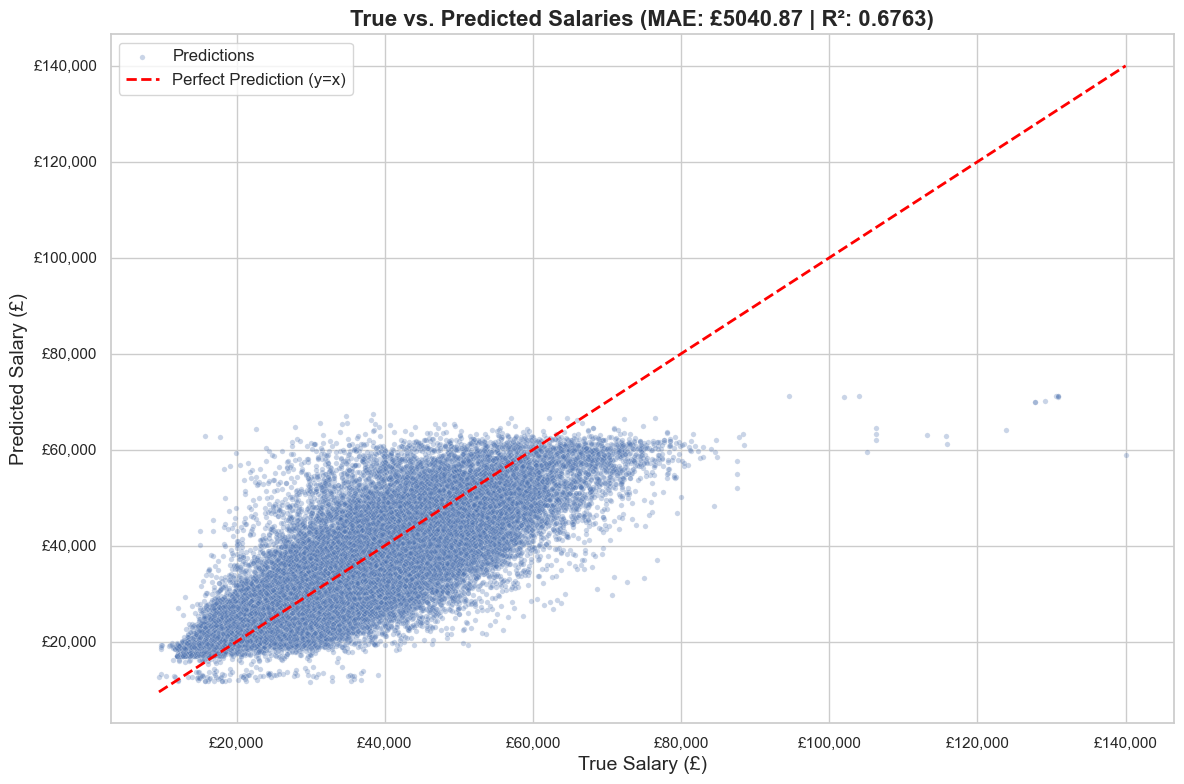

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Painting the Exodia Masterpiece...")

# Set the style to look professional (no boomer default charts here)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. The Scatter Plot
# alpha=0.3 makes the dots see-through so you can see where the data is dense
sns.scatterplot(
    x=y_test, 
    y=final_preds_real, 
    alpha=0.3, 
    color="#4C72B0", 
    s=15, # dot size
    label="Predictions"
)

# 2. The Line of Perfect Prediction (y = x)
# If a dot lands on this red dashed line, your model guessed the exact right penny.
min_val = min(y_test.min(), final_preds_real.min())
max_val = max(y_test.max(), final_preds_real.max())

plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='red', 
    linestyle='--', 
    linewidth=2,
    label="Perfect Prediction (y=x)"
)

# 3. Flex the labels and title
plt.title(f"True vs. Predicted Salaries (MAE: £{final_mae:.2f} | R²: {final_r2:.4f})", fontsize=16, fontweight='bold')
plt.xlabel("True Salary (£)", fontsize=14)
plt.ylabel("Predicted Salary (£)", fontsize=14)

# Format the axes to show "£" (because we are fancy like that)
import matplotlib.ticker as ticker
formatter = ticker.StrMethodFormatter('£{x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(fontsize=12)
plt.tight_layout()

# Render the absolute cinema
plt.show()